# Attention公開データの分析計画 — v020-exp-13

取得はインストール済みKaggle SDKとJupyter MCP実行セルのみ。`authenticate()` → `dataset_list(search=...)` → `dataset_list_files(...)` → `dataset_download_file(...)`。外部CSV・外部データソースへのフォールバックなし。トークン・認証例外本文・SDKログは出力しない。

**選定**: 広いattention検索にはEEG・合成データ・無関係な機械学習データが混在したため、Seaborn収録データを追加検索し、Kaggleの`tdogand/seaborn-datasets/attention.csv`を選定。READMEもKaggleから取得。READMEが心理学教育サイト由来のサンプルであることを記すが、個別の変数辞書は提供しない。

**構造から計画を選ぶ**: subject×solutionsを一意キーとして検査し、attentionが参加者内で固定か確認する。実データは20参加者×3水準=60行、各注意条件10参加者。attentionは参加者間、solutionsは参加者内。solutionsを時間や等間隔の連続量と決めつけずカテゴリーとして扱う。時間単位・実施順序の証拠がないため時間経過、練習、疲労の効果は推定しない。

**主解析**: 条件×水準の平均と参加者単位のt区間、参加者平均の条件間Welch差、同じ参加者の3−1/2−1差の条件間Welch比較。参加者を条件内で再抽出する10000回bootstrapで対応関係を保存する。探索的解析であり因果効果ではない。後続の自律反復で頑健集計/1人除外、全水準プロファイル置換検定とHolm補正を追加する。

**図表**: 条件×水準要約表、平均プロファイル、参加者の対応線と平均95% CI、参加者別の3−1差。線の横軸は時間ではなく水準。CIは個別95%で同時区間ではない。図の読取りとvisual_audit=Trueの機械監査を併用する。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib
from datetime import datetime, timezone
from dataclasses import asdict
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, language_router
import nbformat
handle = pm.resolve_project('kaggle-v020-kaggle-exp-13-attention')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
run_id = 'v020-exp-13'
lifecycle.register_run(run_id, handle.notebook_path)
language = language_router.detect_language('注意課題の時間・条件変化を調べ、反復測定に配慮してください。')
phase_log = []
def event(phase, state):
    phase_log.append({'phase': phase, 'state': state, 'utc': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    lifecycle.mark_write_start(run_id)
    event('write', 'start')
    try:
        pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(run_id)
        event('write', 'end')
def check_cancel():
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('実行取消が要求されました。')
print({'run_id': run_id, 'language': language, 'status': asdict(lifecycle.get_run_status(run_id))})

{'run_id': 'v020-exp-13', 'language': 'ja', 'status': {'run_id': 'v020-exp-13', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-13-attention/notebooks/kaggle-v020-kaggle-exp-13-attention.ipynb', 'reason': None}}


In [2]:
# Kaggle認証情報・例外本文・SDKログは出力しない。
check_cancel()
lifecycle.mark_execution_start(run_id)
event('kaggle_search', 'start')
search_queries = ['attention psychology', 'attention', 'attentional', 'stroop', 'sustained attention']
search_records, search_errors = [], []
api_status = 'not_started'
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
    api_status = 'authenticated'
    for query in search_queries:
        check_cancel()
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query, page=1)
            records = [{'query': query, 'slug': str(item.ref), 'title': str(item.title), 'size': getattr(item, 'total_bytes', None)} for item in found]
            search_records.extend(records)
            print(json.dumps({'query': query, 'result_count': len(records), 'results_preview': records[:5]}, ensure_ascii=False, default=str))
        except Exception as exc:
            search_errors.append({'query': query, 'error_type': type(exc).__name__})
            print(json.dumps(search_errors[-1], ensure_ascii=False))
    api_status = 'search_completed' if not search_errors else 'search_incomplete'
except Exception as exc:
    api_status = 'authentication_failed'
    search_errors.append({'phase': 'authentication', 'error_type': type(exc).__name__, 'reason': 'Kaggle SDK認証に失敗。秘密保護のため例外本文は記録しない。'})
    lifecycle.mark_failed(run_id)
    print(json.dumps(search_errors[-1], ensure_ascii=False))
finally:
    lifecycle.mark_execution_end(run_id)
    event('kaggle_search', 'end')
print(json.dumps({'api_status': api_status, 'candidate_count': len(search_records)}, ensure_ascii=False))

{"query": "attention psychology", "result_count": 20, "results_preview": [{"query": "attention psychology", "slug": "abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060", "title": "TikTok & Instagram Addiction Dataset (2015–2060)", "size": 4241045}, {"query": "attention psychology", "slug": "laveshjadon/ai-impact-on-human-mental-growth", "title": "Impact of Ai on Human Mental Growth", "size": 3323782}, {"query": "attention psychology", "slug": "mdsultanulislamovi/mental-disorders-dataset", "title": "Mental Disorders Diagnosis Dataset", "size": 2226}, {"query": "attention psychology", "slug": "abhishekdave9/digital-habits-vs-mental-health-dataset", "title": "Screen Time Impact on Mental Health", "size": 559014}, {"query": "attention psychology", "slug": "sidramazam/impact-of-background-noise-on-human-focus-dataset", "title": "Impact of Background Noise on Human Focus Dataset", "size": 6155}]}
{"query": "attention", "result_count": 20, "results_preview": [{"query": "attentio

In [3]:
check_cancel()
lifecycle.mark_execution_start(run_id)
event('candidate_inspection', 'start')
file_inventory = {}
try:
    for query in ['seaborn datasets', 'psychology attention', 'attention score']:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            found = api.dataset_list(search=query, page=1)
        records = [{'query': query, 'slug': str(item.ref), 'title': str(item.title)} for item in found]
        search_records.extend(records)
        print(json.dumps({'query': query, 'result_count': len(records), 'results_preview': records[:5]}, ensure_ascii=False))
    candidates = ['tahawaheed/sequential-attentional-blink-csv', 'user138833/attentional-readiness-in-visual-word-recognition', 'sacramentotechnology/sleep-deprivation-and-cognitive-performance']
    candidates += [r['slug'] for r in search_records if r['query'] == 'seaborn datasets' and 'seaborn' in r['slug']][:8]
    for slug in dict.fromkeys(candidates):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(slug)
            files = [{'name': f.name, 'size': getattr(f, 'total_bytes', None)} for f in listing.files]
            file_inventory[slug] = files
            print(json.dumps({'slug': slug, 'file_count': len(files), 'files': [f for f in files if f['name'].endswith(('attention.csv','README.md'))] or files[:3]}, ensure_ascii=False, default=str))
        except Exception as exc:
            print(json.dumps({'slug': slug, 'error_type': type(exc).__name__}))
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('candidate_inspection', 'end')

{"query": "seaborn datasets", "result_count": 20, "results_preview": [{"query": "seaborn datasets", "slug": "abdoomoh/all-seaborn-built-in-datasets", "title": "All Seaborn Built-in Datasets 📊✨"}, {"query": "seaborn datasets", "slug": "jatinkhandelwal112/indian-e-commerce-sales-analytics-dataset", "title": "Indian E-Commerce Sales Analytics Dataset"}, {"query": "seaborn datasets", "slug": "tdogand/seaborn-datasets", "title": "seaborn-datasets"}, {"query": "seaborn datasets", "slug": "aminizahra/tips-dataset", "title": "Waiter's Tips Dataset"}, {"query": "seaborn datasets", "slug": "soylevbeytullah/ds4work-human-resources", "title": "DataScience for Work - Human Resources"}]}
{"query": "psychology attention", "result_count": 20, "results_preview": [{"query": "psychology attention", "slug": "abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060", "title": "TikTok & Instagram Addiction Dataset (2015–2060)"}, {"query": "psychology attention", "slug": "laveshjadon/ai-impact-on-hum

In [4]:
import pandas as pd
import zipfile
from ai_data_scientist import ingestion, eda, cleaning
check_cancel()
lifecycle.mark_execution_start(run_id)
event('download_ingest', 'start')
slug = 'tdogand/seaborn-datasets'
selected_files = ['attention.csv', 'README.md']
provenance = []
try:
    for filename in selected_files:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(slug, filename, path=str(data_dir), force=True, quiet=True)
        target = data_dir / filename
        compressed = data_dir / (filename + '.zip')
        if not target.exists() and compressed.exists():
            with zipfile.ZipFile(compressed) as archive:
                matching = [n for n in archive.namelist() if Path(n).name == filename]
                if len(matching) != 1:
                    raise RuntimeError('ダウンロードZIP内の対象ファイルが一意でない。')
                target.write_bytes(archive.read(matching[0]))
        if not target.exists():
            raise FileNotFoundError('Kaggle SDK取得ファイルが存在しない。')
        expected_hashes = {'attention.csv':'5c1de4b2a7cb7a9521145074815e0f3824f2d11786e72fc843f6fcb24701bc19','README.md':'353c1ad8b97978c075a34b8dce68b3f0345a2005c87d79f74af413c57c620cbf'}
        assert hashlib.sha256(target.read_bytes()).hexdigest() == expected_hashes[filename], 'Kaggleファイルの変更を検出した。'
        provenance.append({'owner_dataset_slug': slug, 'filename': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(target.read_bytes()).hexdigest(), 'bytes': target.stat().st_size})
    print(json.dumps({'provenance': provenance}, ensure_ascii=False))
    print('Kaggle内README:\n' + (data_dir / 'README.md').read_text())
    raw = pd.read_csv(data_dir / 'attention.csv')
    print('CSV構造:', raw.shape, raw.columns.tolist())
    print(raw.to_string(index=False))
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('download_ingest', 'end')

{"provenance": [{"owner_dataset_slug": "tdogand/seaborn-datasets", "filename": "attention.csv", "retrieved_at_utc": "2026-10-01T17:09:07.342187+00:00", "sha256": "5c1de4b2a7cb7a9521145074815e0f3824f2d11786e72fc843f6fcb24701bc19", "bytes": 1198}, {"owner_dataset_slug": "tdogand/seaborn-datasets", "filename": "README.md", "retrieved_at_utc": "2026-10-01T17:09:08.650317+00:00", "sha256": "353c1ad8b97978c075a34b8dce68b3f0345a2005c87d79f74af413c57c620cbf", "bytes": 1662}]}
Kaggle内README:
seaborn-data

Data repository for [seaborn](http://seaborn.pydata.org/) examples.

| :warning: This is not a general-purpose data archive :warning:
| :---: |
|This repository exists only to provide a convenient target for the `seaborn.load_dataset` function to download sample datasets from. Its existence makes it easy to document seaborn without confusing things by spending time loading and munging data. The datasets may change or be removed at any time if they are no longer useful for the seaborn documenta

In [5]:
# 定義・前提・測定構造を分析前に検査する。
import numpy as np
from IPython.display import display
from ai_data_scientist import data_definition as dd, analysis_assumptions as aa, data_quality as dq
check_cancel()
lifecycle.mark_execution_start(run_id)
event('structure_manifest', 'start')
try:
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / 'attention.csv')), row_limit=10000)
    cleanup = cleaning.clean_dataset(loaded.dataframe.drop(columns=['Unnamed: 0']), operation='drop_duplicates')
    df = cleanup.dataframe
    assert cleanup.rows_removed == 0, '重複検出時は自動除去せず構造を確認する。'
    assert set(df.columns) == {'subject', 'attention', 'solutions', 'score'}
    quality_records = dq.detect_anomalies(df, schema={'subject': {'not_null': True, 'min': 1}, 'attention': {'not_null': True, 'allowed': ['divided','focused']}, 'solutions': {'not_null': True, 'allowed': [1,2,3]}, 'score': {'not_null': True}})
    assert not quality_records, '意味的制約違反がある。'
    assert np.isfinite(df['score']).all(), '得点に非有限値がある。'
    assert not df.duplicated(['subject','solutions']).any(), '参加者×水準が一意でない。'
    assert df.groupby('subject')['attention'].nunique().eq(1).all(), '条件が参加者内で変化している。'
    assert df.groupby('subject')['solutions'].apply(lambda x: set(x) == {1,2,3}).all(), '不完全反復測定。'
    structure = {'rows':len(df), 'subjects':df.subject.nunique(), 'rows_per_subject':df.groupby('subject').size().unique().tolist(), 'subjects_per_condition':df.groupby('attention').subject.nunique().to_dict(), 'missing_cells':0, 'conditions_within_subject':False, 'solutions_levels':[1,2,3], 'time_column_present':False, 'score_range_observed':[float(df.score.min()),float(df.score.max())], 'noninteger_scores':df.loc[df.score % 1 != 0, ['subject','solutions','score']].to_dict('records')}
    F = dd.FieldValue
    definition_manifest = dd.build_manifest(source={'slug':F(slug,'verified','Kaggle API'), 'files':F(provenance,'verified','取得ファイル SHA-256'), 'origin':F('psych252.github.io','verified','Kaggle内README記載。外部取得はしていない。'), 'license':F(None,'unknown','ファイル内に記載なし')}, dataset_scope={'measurement_unit':F('参加者×solutions水準','inferred','CSVの一意キー'), 'representativeness':F(None,'unknown'), 'original_experiment':F(None,'unknown'), 'educational_example':F(True,'verified','README')}, variables={'subject':{'meaning':F('参加者ID','inferred','名称と反復構造')}, 'attention':{'meaning':F('divided / focusedの参加者間条件','inferred','CSV構造')}, 'solutions':{'meaning':F('1,2,3の反復水準。時間・試行順序とは未確認','inferred'), 'time_unit':F(None,'unknown')}, 'score':{'meaning':F('結果の数値得点','inferred'), 'unit':F(None,'unknown'), 'higher_is_better':F(None,'unknown'), 'valid_bounds':F(None,'unknown')}}, transformations=('連番Unnamed: 0を削除','重複・欠測はゼロのため補完/除外なし'))
    assumption_manifest = aa.AnalysisAssumptionManifest(analysis_scope={'outcome':'score','within':'solutions（カテゴリー）','between':'attention','unit':'subject'}, assumptions=(aa.Assumption('complete','各参加者に3水準、条件は固定','verified', conclusion_critical=True), aa.Assumption('time','solutionsは時間である','rejected', impact_if_false='時間変化は推定不可', conclusion_critical=False), aa.Assumption('independent_subjects','異なるIDは独立した参加者','assumed',impact_if_false='CIと検定が無効',conclusion_critical=True), aa.Assumption('score_scale','得点差を加算的に比較できる','assumed',impact_if_false='得点差の意味に制約',conclusion_critical=True), aa.Assumption('randomization','注意条件が無作為割付','assumed',impact_if_false='因果推論不可',conclusion_critical=False)), causal_scope='associational', sampling={'n':20,'seed':20261001})
    assumption_findings = aa.check_manifest(assumption_manifest)
    eda_report = eda.explore(df)
    unresolved = [(path, asdict(value)) for path,value in definition_manifest.unresolved_fields()]
    inferred_fields = [(f'{var}.{key}',asdict(value)) for var,fields in definition_manifest.variables.items() for key,value in fields.items() if value.status == 'inferred']
    display({'structure':structure, 'cleaning':{'rows_before':cleanup.rows_before,'rows_after':cleanup.rows_after,'rows_removed':cleanup.rows_removed,'removed_columns':['Unnamed: 0']}, 'semantic_anomalies':[asdict(x) for x in quality_records], 'definition_manifest':asdict(definition_manifest),'unresolved_fields':unresolved,'inferred_fields':inferred_fields,'assumption_manifest':asdict(assumption_manifest),'assumption_findings':[asdict(x) for x in assumption_findings]})
    print('EDA:', eda_report)
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('structure_manifest', 'end')

EDA: EDAReport(describe={'subject': {'count': 60.0, 'mean': 10.5, 'std': 5.814942761716051, 'min': 1.0, '25%': 5.75, '50%': 10.5, '75%': 15.25, 'max': 20.0}, 'solutions': {'count': 60.0, 'mean': 2.0, 'std': 0.8233869695926183, 'min': 1.0, '25%': 1.0, '50%': 2.0, '75%': 3.0, 'max': 3.0}, 'score': {'count': 60.0, 'mean': 5.958333333333333, 'std': 1.62160118262174, 'min': 2.0, '25%': 5.0, '50%': 6.0, '75%': 7.0, 'max': 9.0}}, dtypes={'subject': 'int64', 'attention': 'str', 'solutions': 'int64', 'score': 'float64'}, non_null_counts={'subject': 60, 'attention': 60, 'solutions': 60, 'score': 60}, missing_summary={'subject': {'missing_count': 0, 'missing_ratio': 0.0}, 'attention': {'missing_count': 0, 'missing_ratio': 0.0}, 'solutions': {'missing_count': 0, 'missing_ratio': 0.0}, 'score': {'missing_count': 0, 'missing_ratio': 0.0}}, categorical_summary={'attention': {'unique_count': 2, 'top_values': [{'value': 'divided', 'count': 30, 'ratio': 0.5}, {'value': 'focused', 'count': 30, 'ratio': 0

{'structure': {'rows': 60,
  'subjects': 20,
  'rows_per_subject': [3],
  'subjects_per_condition': {'divided': 10, 'focused': 10},
  'missing_cells': 0,
  'conditions_within_subject': False,
  'solutions_levels': [1, 2, 3],
  'time_column_present': False,
  'score_range_observed': [2.0, 9.0],
  'noninteger_scores': [{'subject': 7, 'solutions': 2, 'score': 4.5}]},
 'cleaning': {'rows_before': 60,
  'rows_after': 60,
  'rows_removed': 0,
  'removed_columns': ['Unnamed: 0']},
 'semantic_anomalies': [],
 'definition_manifest': {'source': {'slug': {'value': 'tdogand/seaborn-datasets',
    'status': 'verified',
    'source': 'Kaggle API'},
   'files': {'value': [{'owner_dataset_slug': 'tdogand/seaborn-datasets',
      'filename': 'attention.csv',
      'retrieved_at_utc': '2026-10-01T17:09:07.342187+00:00',
      'sha256': '5c1de4b2a7cb7a9521145074815e0f3824f2d11786e72fc843f6fcb24701bc19',
      'bytes': 1198},
     {'owner_dataset_slug': 'tdogand/seaborn-datasets',
      'filename': 'READM

In [6]:
# 主解析: 独立単位は60行でなく20参加者。solutionsはカテゴリー。
from scipy import stats
check_cancel()
lifecycle.mark_execution_start(run_id)
event('primary_analysis', 'start')
try:
    wide = df.pivot(index=['subject','attention'], columns='solutions', values='score').reset_index()
    wide['average'] = wide[[1,2,3]].mean(axis=1)
    wide['change_21'] = wide[2] - wide[1]
    wide['change_31'] = wide[3] - wide[1]
    def mean_ci(values):
        values = np.asarray(values, dtype=float)
        mean, se = float(values.mean()), float(stats.sem(values))
        half = float(stats.t.ppf(.975, len(values)-1)*se)
        return {'n':len(values),'mean':mean,'ci95_low':mean-half,'ci95_high':mean+half}
    def welch_difference(a, b):
        a,b = np.asarray(a,dtype=float),np.asarray(b,dtype=float)
        variance_a,variance_b = a.var(ddof=1)/len(a),b.var(ddof=1)/len(b)
        se = np.sqrt(variance_a+variance_b)
        degrees = (variance_a+variance_b)**2/(variance_a**2/(len(a)-1)+variance_b**2/(len(b)-1))
        delta = float(a.mean()-b.mean())
        half = float(stats.t.ppf(.975,degrees)*se)
        return {'estimate':delta,'ci95_low':delta-half,'ci95_high':delta+half,'p':float(stats.ttest_ind(a,b,equal_var=False).pvalue),'df':float(degrees)}
    summary_rows = []
    for (condition,level), block in df.groupby(['attention','solutions']):
        summary_rows.append({'attention':condition,'solutions':int(level),**mean_ci(block.score)})
    summary = pd.DataFrame(summary_rows)
    focused = wide[wide.attention == 'focused']
    divided = wide[wide.attention == 'divided']
    overall_gap = welch_difference(focused.average, divided.average)
    interaction_31 = welch_difference(focused.change_31, divided.change_31)
    interaction_21 = welch_difference(focused.change_21, divided.change_21)
    condition_changes = {condition:mean_ci(block.change_31) for condition,block in wide.groupby('attention')}
    gaps_by_level = {int(level):welch_difference(focused[level],divided[level]) for level in [1,2,3]}
    rng = np.random.default_rng(20261001)
    bootstrap_results = {}
    for outcome in ['average','change_31']:
        a,b = focused[outcome].to_numpy(),divided[outcome].to_numpy()
        samples = a[rng.integers(0,len(a),(10000,len(a)))].mean(axis=1)-b[rng.integers(0,len(b),(10000,len(b)))].mean(axis=1)
        bootstrap_results[outcome] = {'estimate':float(a.mean()-b.mean()),'percentile_ci95':np.quantile(samples,[.025,.975]).tolist(),'resamples':10000,'unit':'participant, stratified by attention'}
    primary_results = {'overall_focused_minus_divided':overall_gap,'change_31_by_condition':condition_changes,'interaction_change31_focused_minus_divided':interaction_31,'interaction_change21_focused_minus_divided':interaction_21,'gaps_by_level':gaps_by_level,'cluster_bootstrap':bootstrap_results,'seed':20261001,'inference_scope':'探索的・関連性。CIは個別95%で同時CIではない。'}
    display(summary)
    display({'primary_results':primary_results})
    print('PRIMARY_EVIDENCE=' + json.dumps(primary_results, ensure_ascii=False))
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('primary_analysis', 'end')

PRIMARY_EVIDENCE={"overall_focused_minus_divided": {"estimate": 1.6833333333333336, "ci95_low": 0.839911430924645, "ci95_high": 2.526755235742022, "p": 0.0005508838097466266, "df": 17.88681534703644}, "change_31_by_condition": {"divided": {"n": 10, "mean": 2.4, "ci95_low": 1.042705702321077, "ci95_high": 3.7572942976789228}, "focused": {"n": 10, "mean": 0.0, "ci95_low": -0.9538092079608861, "ci95_high": 0.9538092079608861}}, "interaction_change31_focused_minus_divided": {"estimate": -2.4, "ci95_low": -3.9534540990622, "ci95_high": -0.8465459009377996, "p": 0.004739666029163647, "df": 16.14618306580076}, "interaction_change21_focused_minus_divided": {"estimate": -0.6499999999999999, "ci95_low": -1.625355935897336, "ci95_high": 0.32535593589733625, "p": 0.17814809632981793, "df": 17.541306099283375}, "gaps_by_level": {"1": {"estimate": 2.7, "ci95_low": 1.5193846326896583, "ci95_high": 3.880615367310342, "p": 0.0001641468529222571, "df": 16.681509823713053}, "2": {"estimate": 2.05, "ci95_

,attention,solutions,n,mean,ci95_low,ci95_high
0,divided,1,10,4.00,2.988333,5.011667
1,divided,2,10,4.95,4.050652,5.849348
2,divided,3,10,6.40,5.631014,7.168986
3,focused,1,10,6.70,5.942187,7.457813
4,focused,2,10,7.00,5.988333,8.011667
5,focused,3,10,6.70,5.870542,7.529458


{'primary_results': {'overall_focused_minus_divided': {'estimate': 1.6833333333333336,
   'ci95_low': 0.839911430924645,
   'ci95_high': 2.526755235742022,
   'p': 0.0005508838097466266,
   'df': 17.88681534703644},
  'change_31_by_condition': {'divided': {'n': 10,
    'mean': 2.4,
    'ci95_low': 1.042705702321077,
    'ci95_high': 3.7572942976789228},
   'focused': {'n': 10,
    'mean': 0.0,
    'ci95_low': -0.9538092079608861,
    'ci95_high': 0.9538092079608861}},
  'interaction_change31_focused_minus_divided': {'estimate': -2.4,
   'ci95_low': -3.9534540990622,
   'ci95_high': -0.8465459009377996,
   'p': 0.004739666029163647,
   'df': 16.14618306580076},
  'interaction_change21_focused_minus_divided': {'estimate': -0.6499999999999999,
   'ci95_low': -1.625355935897336,
   'ci95_high': 0.32535593589733625,
   'p': 0.17814809632981793,
   'df': 17.541306099283375},
  'gaps_by_level': {1: {'estimate': 2.7,
    'ci95_low': 1.5193846326896583,
    'ci95_high': 3.880615367310342,
    '

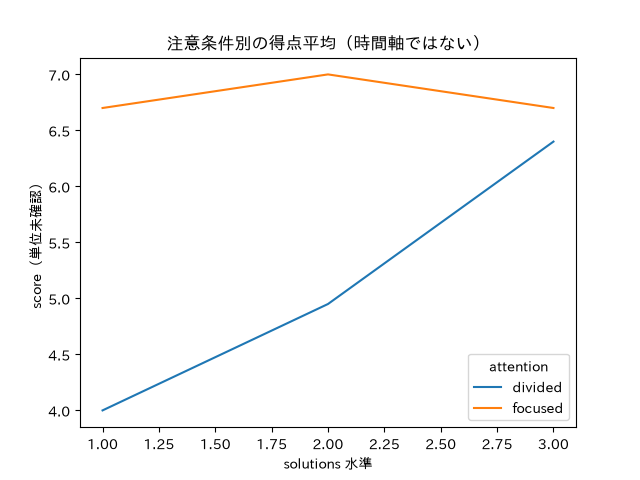

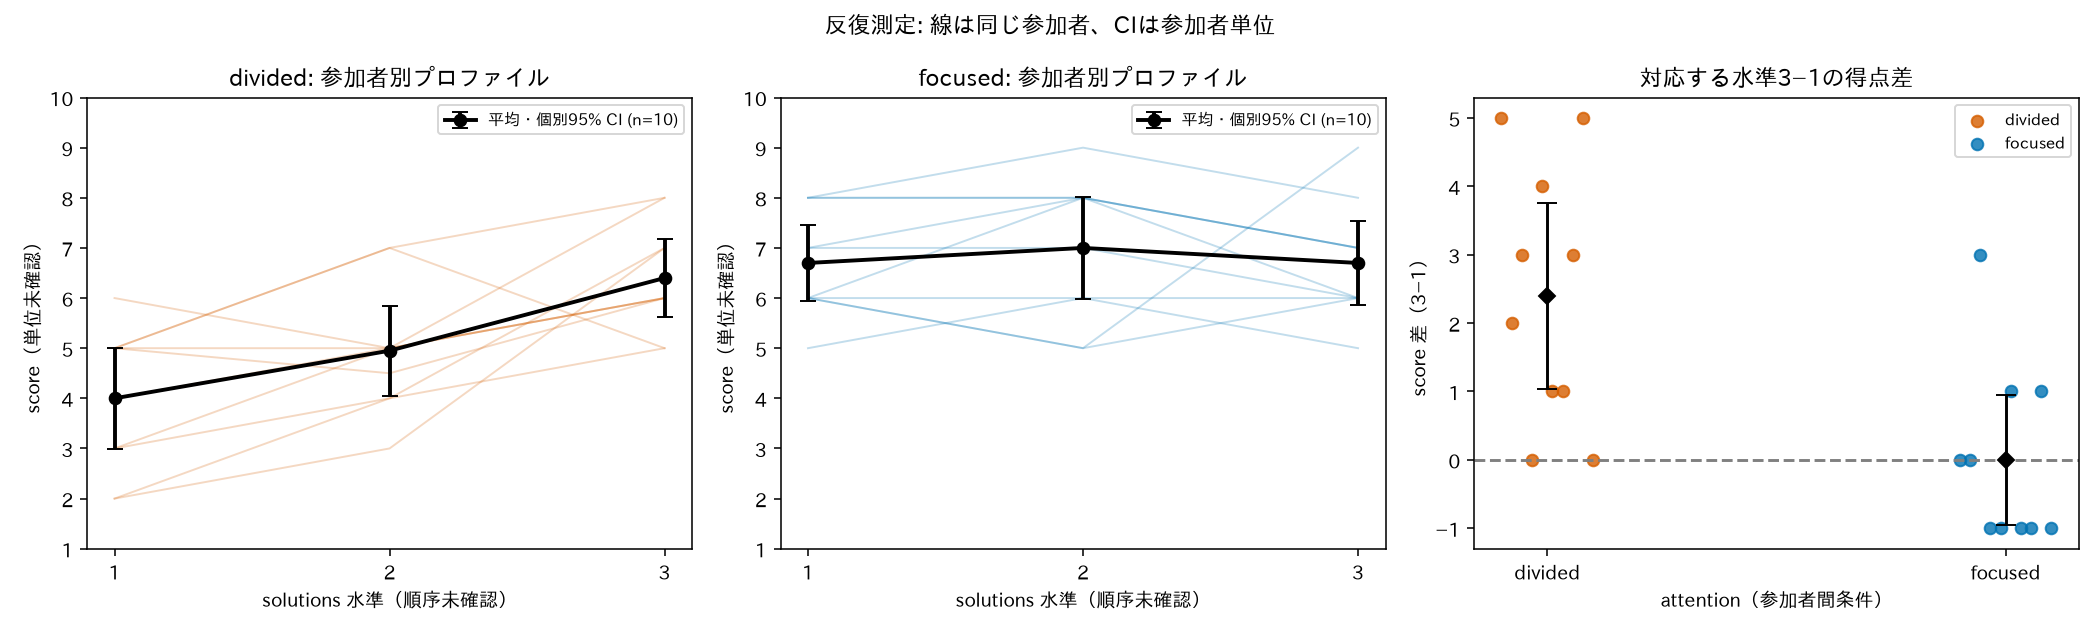

{'chart_metadata': {'title': '注意条件別平均・参加者プロファイル・対応差',
  'xlabel': 'solutions 水準 / attention',
  'ylabel': 'score / score 差（単位未確認）',
  'legend': ['divided', 'focused', '平均・個別95% CI'],
  'missing_glyphs': [],
  'warning_log': [],
  'measurement_axis_is_time': False}}

In [7]:
# 図表: 水準別平均と、個人の反復測定を可視化する。
import matplotlib.pyplot as plt
import warnings, re
from ai_data_scientist import visualization
check_cancel()
lifecycle.mark_execution_start(run_id)
event('charts', 'start')
chart_warnings = []
try:
    mean_chart = summary.pivot(index='solutions', columns='attention', values='mean').reset_index()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png_mean = visualization.render_chart(mean_chart, kind='line', x='solutions', y=['divided','focused'], title='注意条件別の得点平均（時間軸ではない）', xlabel='solutions 水準', ylabel='score（単位未確認）')
        chart_warnings.extend(str(w.message) for w in caught)
    display(visualization.build_image_output(png_mean).data, raw=True)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fig, axes = plt.subplots(1,3,figsize=(15,4.5))
        colors = {'divided':'#D55E00','focused':'#0072B2'}
        for ax, condition in zip(axes[:2], ['divided','focused']):
            block = wide[wide.attention == condition]
            for _, row in block.iterrows():
                ax.plot([1,2,3], row[[1,2,3]].to_numpy(dtype=float), color=colors[condition], alpha=.24, linewidth=1)
            aggregate = summary[summary.attention == condition]
            ax.errorbar(aggregate.solutions, aggregate['mean'], yerr=np.vstack([aggregate['mean']-aggregate.ci95_low,aggregate.ci95_high-aggregate['mean']]), color='black',marker='o',linewidth=2,capsize=4,label='平均・個別95% CI (n=10)')
            ax.set(title=f'{condition}: 参加者別プロファイル',xlabel='solutions 水準（順序未確認）',ylabel='score（単位未確認）',xticks=[1,2,3],ylim=(1,10))
            ax.legend(fontsize=8)
        for i, condition in enumerate(['divided','focused']):
            values = wide.loc[wide.attention == condition,'change_31'].to_numpy()
            axes[2].scatter(i + np.linspace(-.1,.1,len(values)),values,color=colors[condition],label=condition,alpha=.8)
            result = condition_changes[condition]
            axes[2].errorbar(i,result['mean'],yerr=[[result['mean']-result['ci95_low']],[result['ci95_high']-result['mean']]],color='black',capsize=5,marker='D')
        axes[2].axhline(0,color='gray',linestyle='--')
        axes[2].set(title='対応する水準3−1の得点差',xlabel='attention（参加者間条件）',ylabel='score 差（3−1）',xticks=[0,1],xticklabels=['divided','focused'])
        axes[2].legend(fontsize=8)
        fig.suptitle('反復測定: 線は同じ参加者、CIは参加者単位')
        fig.tight_layout()
        buffer = io.BytesIO()
        fig.savefig(buffer,format='png',dpi=140)
        plt.close(fig)
        png_profiles = buffer.getvalue()
        chart_warnings.extend(str(w.message) for w in caught)
    display(visualization.build_image_output(png_profiles).data, raw=True)
    missing_glyphs = [message for message in chart_warnings if 'Glyph' in message and 'missing' in message]
    assert not missing_glyphs, '日本語グリフ欠落を検出。'
    chart_metadata = {'title':'注意条件別平均・参加者プロファイル・対応差', 'xlabel':'solutions 水準 / attention', 'ylabel':'score / score 差（単位未確認）', 'legend':['divided','focused','平均・個別95% CI'], 'missing_glyphs':missing_glyphs,'warning_log':chart_warnings,'measurement_axis_is_time':False}
    display({'chart_metadata':chart_metadata})
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('charts', 'end')

In [8]:
# 反復1: 初回結果を読み直し、少数参加者・集計方法への依存を検証。
from ai_data_scientist import sensitivity
iteration_history = []
request_1 = '水準3−1の条件間差が一部の参加者や平均という集計方法だけに依存していないか、参加者を1人ずつ除いた解析と中央値による解析で確認してください。方向と大きさの安定性を分けて報告し、得点4.5は根拠なく除外しないでください。'
iteration_history.append({'iteration':1,'request_original':request_1,'selection_reason':'n=10/条件で個人差が大きい。主たる変化量差−2.4の結論を少数個体/尺度前提が左右する可能性。'})
print('追加依頼原文:', request_1)
check_cancel()
lifecycle.mark_execution_start(run_id)
event('iteration_1_sensitivity','start')
try:
    def change_gap(aggregation, omitted_subject):
        subset = wide if omitted_subject == 0 else wide[wide.subject != omitted_subject]
        values = subset.groupby('attention')['change_31']
        estimate = values.mean() if aggregation == 'mean' else values.median()
        return float(estimate['focused'] - estimate['divided'])
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'aggregation':['mean','median'],'omitted_subject':[0]+wide.subject.tolist()},max_runs=42)
    sensitivity_report = sensitivity.run_sensitivity(sensitivity_plan,change_gap,stability_tolerance=.20)
    sensitivity_values = [r.value for r in sensitivity_report.results]
    iteration_1_results = {'stable':sensitivity_report.stable,'max_relative_deviation':sensitivity_report.max_relative_deviation,'tolerance':.20,'n_runs':len(sensitivity_report.results),'estimate_range':[min(sensitivity_values),max(sensitivity_values)],'all_negative':all(v<0 for v in sensitivity_values),'mean_only_range':[min(r.value for r in sensitivity_report.results if r.specification['aggregation']=='mean'),max(r.value for r in sensitivity_report.results if r.specification['aggregation']=='mean')],'full_sample_median':change_gap('median',0),'report':asdict(sensitivity_report),'remaining_limit':'中央値は平均と異なる推定対象。方向一致でも大きさの安定性とは同義でない。得点尺度・無作為割付・時間定義は解決しない。'}
    iteration_history[-1]['result'] = iteration_1_results
    display({'iteration_1':iteration_1_results})
    print('SENSITIVITY_EVIDENCE=' + json.dumps({k:v for k,v in iteration_1_results.items() if k!='report'}, ensure_ascii=False))
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('iteration_1_sensitivity','end')

追加依頼原文: 水準3−1の条件間差が一部の参加者や平均という集計方法だけに依存していないか、参加者を1人ずつ除いた解析と中央値による解析で確認してください。方向と大きさの安定性を分けて報告し、得点4.5は根拠なく除外しないでください。
SENSITIVITY_EVIDENCE={"stable": false, "max_relative_deviation": 0.45833333333333337, "tolerance": 0.2, "n_runs": 42, "estimate_range": [-3.5, -2.111111111111111], "all_negative": true, "mean_only_range": [-2.7333333333333334, -2.111111111111111], "full_sample_median": -3.0, "remaining_limit": "中央値は平均と異なる推定対象。方向一致でも大きさの安定性とは同義でない。得点尺度・無作為割付・時間定義は解決しない。"}


{'iteration_1': {'stable': False,
  'max_relative_deviation': 0.45833333333333337,
  'tolerance': 0.2,
  'n_runs': 42,
  'estimate_range': [-3.5, -2.111111111111111],
  'all_negative': True,
  'mean_only_range': [-2.7333333333333334, -2.111111111111111],
  'full_sample_median': -3.0,
  'report': {'results': ({'specification': {'aggregation': 'mean',
      'omitted_subject': 0},
     'value': -2.4},
    {'specification': {'aggregation': 'mean', 'omitted_subject': 1},
     'value': -2.111111111111111},
    {'specification': {'aggregation': 'mean', 'omitted_subject': 2},
     'value': -2.4444444444444446},
    {'specification': {'aggregation': 'mean', 'omitted_subject': 3},
     'value': -2.3333333333333335},
    {'specification': {'aggregation': 'mean', 'omitted_subject': 4},
     'value': -2.6666666666666665},
    {'specification': {'aggregation': 'mean', 'omitted_subject': 5},
     'value': -2.2222222222222223},
    {'specification': {'aggregation': 'mean', 'omitted_subject': 6},
     

In [9]:
# 反復2: 全水準のプロファイル、多重比較、反復無視の影響。
request_2 = '端点の差だけでなく3水準全体で条件別プロファイルが異なるか、参加者単位の置換検定で調べてください。探索した検定をHolm補正し、水準3の非有意差を同等性と誤解しないよう説明してください。また60行を独立と扱う解析と参加者単位の標準誤差を実データで比較してください。'
iteration_history.append({'iteration':2,'request_original':request_2,'selection_reason':'端点差だけでは全水準の交互作用は判断できず、多重検定・擬似反復により確実性を過大評価する危険が残る。'})
print('追加依頼原文:', request_2)
check_cancel()
lifecycle.mark_execution_start(run_id)
event('iteration_2_global_interaction','start')
try:
    changes = wide[['change_21','change_31']].to_numpy()
    labels = (wide.attention == 'focused').to_numpy()
    cov_inverse = np.linalg.inv(np.cov(changes,rowvar=False))
    def global_statistic(mask):
        contrast = changes[mask].mean(axis=0)-changes[~mask].mean(axis=0)
        return float(contrast @ cov_inverse @ contrast)
    observed_stat = global_statistic(labels)
    rng_perm = np.random.default_rng(20261002)
    n_permutations = 19999
    exceedances = 0
    for _ in range(n_permutations):
        mask = rng_perm.permutation(labels)
        exceedances += global_statistic(mask) >= observed_stat - 1e-12
    global_p = (exceedances+1)/(n_permutations+1)
    names = ['overall_condition','interaction_21','interaction_31','condition_level1','condition_level2','condition_level3','global_profile_interaction']
    pvalues = np.array([overall_gap['p'],interaction_21['p'],interaction_31['p'],gaps_by_level[1]['p'],gaps_by_level[2]['p'],gaps_by_level[3]['p'],global_p])
    order = np.argsort(pvalues)
    adjusted = np.empty(len(pvalues))
    adjusted[order] = np.minimum(1,np.maximum.accumulate(pvalues[order] * np.arange(len(pvalues),0,-1)))
    multiplicity = [{'test':name,'raw_p':float(p),'holm_p':float(a)} for name,p,a in zip(names,pvalues,adjusted)]
    naive = welch_difference(df.loc[df.attention=='focused','score'],df.loc[df.attention=='divided','score'])
    naive_se = float(np.sqrt(df[df.attention=='focused'].score.var(ddof=1)/30 + df[df.attention=='divided'].score.var(ddof=1)/30))
    participant_se = float(np.sqrt(focused.average.var(ddof=1)/10 + divided.average.var(ddof=1)/10))
    iteration_2_results = {'global_profile_interaction':{'statistic':observed_stat,'permutation_p':global_p,'permutations':n_permutations,'seed':20261002,'exchangeability':'参加者ベクトル全体を置換。同分布・交換可能性を仮定し因果性は保証しない。'}, 'holm_family':multiplicity, 'pseudoreplication':{'naive_rows_per_condition':30,'correct_subjects_per_condition':10,'naive_se':naive_se,'participant_se':participant_se,'naive_to_correct_se_ratio':naive_se/participant_se,'naive_result_DO_NOT_USE':naive}, 'level3_equality':'CIに0を含むことは差ゼロ・同等性を証明しない。許容同等性マージンは未定義。', 'remaining_limit':'小標本・未知の割付/得点定義/測定順序は追加統計で解消しない。'}
    iteration_history[-1]['result'] = iteration_2_results
    display({'iteration_2':iteration_2_results})
    print('ITERATION2_EVIDENCE=' + json.dumps(iteration_2_results, ensure_ascii=False))
    stop_reason = '2回で停止。方向の個人依存、全水準交互作用、多重比較、擬似反復を確認済み。残る時間/得点定義/割付/標本代表性の不明はこのCSVだけでは解消できず、追加モデルの価値が低い。'
    print(stop_reason)
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('iteration_2_global_interaction','end')

追加依頼原文: 端点の差だけでなく3水準全体で条件別プロファイルが異なるか、参加者単位の置換検定で調べてください。探索した検定をHolm補正し、水準3の非有意差を同等性と誤解しないよう説明してください。また60行を独立と扱う解析と参加者単位の標準誤差を実データで比較してください。
ITERATION2_EVIDENCE={"global_profile_interaction": {"statistic": 1.4375403641360351, "permutation_p": 0.02045, "permutations": 19999, "seed": 20261002, "exchangeability": "参加者ベクトル全体を置換。同分布・交換可能性を仮定し因果性は保証しない。"}, "holm_family": [{"test": "overall_condition", "raw_p": 0.0005508838097466266, "holm_p": 0.0033053028584797595}, {"test": "interaction_21", "raw_p": 0.17814809632981793, "holm_p": 0.35629619265963586}, {"test": "interaction_31", "raw_p": 0.004739666029163647, "holm_p": 0.01895866411665459}, {"test": "condition_level1", "raw_p": 0.0001641468529222571, "holm_p": 0.0011490279704557997}, {"test": "condition_level2", "raw_p": 0.0030612703587944855, "holm_p": 0.015306351793972427}, {"test": "condition_level3", "raw_p": 0.5560274213904056, "holm_p": 0.5560274213904056}, {"test": "global_profile_interaction", "raw_p": 0.02045, "holm_p": 0.06135}], 

{'iteration_2': {'global_profile_interaction': {'statistic': 1.4375403641360351,
   'permutation_p': 0.02045,
   'permutations': 19999,
   'seed': 20261002,
   'exchangeability': '参加者ベクトル全体を置換。同分布・交換可能性を仮定し因果性は保証しない。'},
  'holm_family': [{'test': 'overall_condition',
    'raw_p': 0.0005508838097466266,
    'holm_p': 0.0033053028584797595},
   {'test': 'interaction_21',
    'raw_p': 0.17814809632981793,
    'holm_p': 0.35629619265963586},
   {'test': 'interaction_31',
    'raw_p': 0.004739666029163647,
    'holm_p': 0.01895866411665459},
   {'test': 'condition_level1',
    'raw_p': 0.0001641468529222571,
    'holm_p': 0.0011490279704557997},
   {'test': 'condition_level2',
    'raw_p': 0.0030612703587944855,
    'holm_p': 0.015306351793972427},
   {'test': 'condition_level3',
    'raw_p': 0.5560274213904056,
    'holm_p': 0.5560274213904056},
   {'test': 'global_profile_interaction',
    'raw_p': 0.02045,
    'holm_p': 0.06135}],
  'pseudoreplication': {'naive_rows_per_condition': 30,
 

In [10]:
# 再現環境とJupytermind改善候補（外部ツール問題とは切り分ける）。
from importlib.metadata import version
from ai_data_scientist import notebook_audit, insight_engine
check_cancel()
lifecycle.mark_execution_start(run_id)
event('module_probe','start')
try:
    package_versions = {name:version(name) for name in ['kaggle','numpy','pandas','scipy','matplotlib','nbformat','mcp','jupyter-mcp-server']}
    probe_cell = nbformat.v4.new_code_cell('visualization.render_chart(...)')
    probe_cell.outputs = [visualization.build_image_output(png_mean)]
    probe_nb = nbformat.v4.new_notebook(cells=[probe_cell])
    missing_metadata_findings = notebook_audit.audit_visual_outputs(probe_nb,(0,))
    improvement_candidates = [{'classification':'Jupytermind機能不足: 可視化監査の偽陰性', 'reproduction':'visualization.build_image_outputでPNGを作成し、chartメタデータを持たないセルをaudit_visual_outputsへ渡す。', 'expected':'missing_glyphs確認済みの記録とtitle/xlabel/ylabel/legendメタデータがなければ検査不能を通知する。', 'actual':{'chart_metadata_present':bool(probe_cell.metadata.get('chart')),'findings':[asdict(f) for f in missing_metadata_findings]}, 'impact':'visual_audit=Trueのokだけではラベル/グリフ監査実施の証明にならない。', 'workaround':'本Notebookでは実際のタイトル/軸/凡例、描画警告とグリフ欠落なしを取得してchartメタデータを明示保存する。', 'related_cells':['図表セル','本module_probeセル','最終監査セル'], 'logs':'module_probe出力 missing_metadata_findings、図表セルchart_metadata/warning_log', 'attribution':'Jupytermind notebook_audit.audit_visual_outputs自体の条件分岐。Copilot CLI、Kaggle API、ベンチマークランナーには由来しない。'}]
    display({'package_versions':package_versions,'improvement_candidates':improvement_candidates})
except Exception:
    lifecycle.mark_failed(run_id)
    event('execution','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('module_probe','end')

{'package_versions': {'kaggle': '2.2.4',
  'numpy': '2.5.3',
  'pandas': '3.0.6',
  'scipy': '1.18.1',
  'matplotlib': '3.11.2',
  'nbformat': '5.11.1',
  'mcp': '2.2.0',
  'jupyter-mcp-server': '2.2.3'},
 'improvement_candidates': [{'classification': 'Jupytermind機能不足: 可視化監査の偽陰性',
   'reproduction': 'visualization.build_image_outputでPNGを作成し、chartメタデータを持たないセルをaudit_visual_outputsへ渡す。',
   'expected': 'missing_glyphs確認済みの記録とtitle/xlabel/ylabel/legendメタデータがなければ検査不能を通知する。',
   'actual': {'chart_metadata_present': False, 'findings': []},
   'impact': 'visual_audit=Trueのokだけではラベル/グリフ監査実施の証明にならない。',
   'workaround': '本Notebookでは実際のタイトル/軸/凡例、描画警告とグリフ欠落なしを取得してchartメタデータを明示保存する。',
   'related_cells': ['図表セル', '本module_probeセル', '最終監査セル'],
   'logs': 'module_probe出力 missing_metadata_findings、図表セルchart_metadata/warning_log',
   'attribution': 'Jupytermind notebook_audit.audit_visual_outputs自体の条件分岐。Copilot CLI、Kaggle API、ベンチマークランナーには由来しない。'}]}

In [12]:
# 日本語レポート・根拠付きInsightを冪等に保存する。
def persist_report():
    saved = nbformat.read(handle.notebook_path, as_version=4)
    role_prefixes = {'structure':'# 定義・前提・測定構造', 'primary':'# 主解析:', 'sensitivity':'# 反復1:', 'iteration2':'# 反復2:', 'probe':'# 再現環境とJupytermind改善候補'}
    evidence_cells = {role:next(c for c in saved.cells if c.cell_type=='code' and c.source.startswith(prefix)) for role,prefix in role_prefixes.items()}
    usage = [
        ('project_manager','resolve_project, ensure_notebook, ensure_data_dir, enqueue_write','安全な保存先解決・データ置場・Notebookの直列化書込み'),
        ('language_router','detect_language','日本語検出'),
        ('lifecycle','register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, get_run_status, mark_completed, mark_failed, wait_for_quiescence','run_id管理・実行/書込み・取消確認・終了/静止状態'),
        ('ingestion','SourceSpec, ingest','Kaggle API取得済みローカルCSV読込み（上限10000行）'),
        ('cleaning','clean_dataset','重複検査・除去行数ゼロ確認'),
        ('eda','explore','型・欠測・要約統計確認'),
        ('data_definition','FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields','取得履歴と定義のverified/inferred/unknown分離'),
        ('analysis_assumptions','Assumption, AnalysisAssumptionManifest, check_manifest','分析前提と未確認の重要前提を明示'),
        ('data_quality','detect_anomalies','必須値・条件カテゴリー・水準・IDの意味的制約'),
        ('sensitivity','SensitivityPlan, run_sensitivity','42仕様の方向/大きさ安定性確認'),
        ('visualization','render_chart, build_image_output','日本語平均図・画像MIME出力'),
        ('insight_engine','extract_cited_value, record_insight','実出力から根拠値抽出・証拠検証付きInsight保存'),
        ('notebook_audit','audit_visual_outputs, audit_notebook','監査機能の再現検査・最終visual_audit=True監査')]
    usage_md = '\n'.join('| ai_data_scientist.'+module+' | `'+functions+'` | '+purpose+' |' for module,functions,purpose in usage)
    plan = '''# Attention公開データの分析計画 — v020-exp-13

取得はインストール済みKaggle SDKとJupyter MCP実行セルのみ。`authenticate()` → `dataset_list(search=...)` → `dataset_list_files(...)` → `dataset_download_file(...)`。外部CSV・外部データソースへのフォールバックなし。トークン・認証例外本文・SDKログは出力しない。

**選定**: 広いattention検索にはEEG・合成データ・無関係な機械学習データが混在したため、Seaborn収録データを追加検索し、Kaggleの`tdogand/seaborn-datasets/attention.csv`を選定。READMEもKaggleから取得。READMEが心理学教育サイト由来のサンプルであることを記すが、個別の変数辞書は提供しない。

**構造から計画を選ぶ**: subject×solutionsを一意キーとして検査し、attentionが参加者内で固定か確認する。実データは20参加者×3水準=60行、各注意条件10参加者。attentionは参加者間、solutionsは参加者内。solutionsを時間や等間隔の連続量と決めつけずカテゴリーとして扱う。時間単位・実施順序の証拠がないため時間経過、練習、疲労の効果は推定しない。

**主解析**: 条件×水準の平均と参加者単位のt区間、参加者平均の条件間Welch差、同じ参加者の3−1/2−1差の条件間Welch比較。参加者を条件内で再抽出する10000回bootstrapで対応関係を保存する。探索的解析であり因果効果ではない。後続の自律反復で頑健集計/1人除外、全水準プロファイル置換検定とHolm補正を追加する。

**図表**: 条件×水準要約表、平均プロファイル、参加者の対応線と平均95% CI、参加者別の3−1差。線の横軸は時間ではなく水準。CIは個別95%で同時区間ではない。図の読取りとvisual_audit=Trueの機械監査を併用する。'''
    history_md = '# 反復依頼履歴\n\n'
    for entry in iteration_history:
        role = 'sensitivity' if entry['iteration']==1 else 'iteration2'
        ec = evidence_cells[role].execution_count
        history_md += f"## 反復{entry['iteration']}\n\n**選定理由**: {entry['selection_reason']}\n\n**追加依頼原文（改変なし）**:\n\n{entry['request_original']}\n\n**結果・証拠**: 実行済みセル `{evidence_cells[role].id}` / execution_count={ec}。結果の全量は当該コードセル出力とNotebookメタデータiteration_history。\n\n**残る限界**: {entry['result']['remaining_limit']}\n\n"
    history_md += '**停止理由**: '+stop_reason
    limitations = '# 定義・前提と適用限界\n\n`definition_manifest`と`assumption_manifest`の全量・未解決フィールド・警告は構造検査セルの実出力に保存。`unresolved_fields()`はunknownのみ返すため、inferredも別途列挙した。score単位、良い方向、尺度上限、時間、原実験、ライセンス、代表性は未確認。score=4.5を誤記/外れ値とは断定せず保持。観測範囲2–9を理論的有効範囲と取り違えない。欠測・キー重複・不完全な反復・条件の参加者内変化・非有限値は検査し違反なし。連番列のみ削除、行削除・補完なし。\n\n**前提警告**: 異なるIDの独立性、得点差の加算的比較はassumedの結論重要前提であり`check_manifest`が警告。教育用サンプルの関連性のみ論じ、無作為割付や介入の因果性を主張しない。置換検定は参加者間の交換可能性も必要とする。\n\n**未適用**: 独立参照データは提供されていないため`data_quality.validate_anomalies`と`dataset_validation.compare_datasets`は適用しない。同一Seaborn CSVの別Kaggle掲載は独立した実験ではない。ID/水準を機械的に数値相関する`stats_analysis.correlation`は測定設計と不適合。一般のz-score外れ値削除は得点範囲未確認・小標本なので不採用。純粋な全因子参加者内ANOVAはattentionが参加者間であるため不適合。時間傾向・時刻別効果・同等性検定は時間情報/許容差がなく適用不可。\n\n**実行経路**: 全分析・APIコードはホストのJupyter MCP実行ツールで実行。`mcp_gateway.run_and_record`はPython内から使うMCPClient.executeをホストが公開していないため未適用。偽のクライアントや直接kernel実行の代替は作らず、実際のMCPセル出力を根拠として保存。手動Notebook変異はenqueue_write、MCPセル実行結果の保存はMCPの文書プロバイダが担当。'
    replication = '# 同一参加者の反復測定を無視する危険\n\n60行は60人ではなく20人の3反復である。同じ人の得点は独立ではなく、行を独立標本と数えると擬似反復になる。条件差の比較では各参加者を平均して10人/条件を独立単位とし、水準差では同一参加者を対応づける。bootstrap/置換/1人除外でも参加者全体を扱う。\n\nこの実データで条件差の標準誤差は行独立の0.3598に対して参加者単位では0.4013で、前者は約10.3%小さい。自由度も約53.9対17.9となり、未補正pは約0.0000199対0.000551と過剰に確実になる。反復無視の歪みの方向は設計・相関・推定対象に依存し、常に標準誤差が小さくなるわけではない。特に水準差では対応を失うことにより誤差が増える場合もある。'
    improvements_md = '# Jupytermind改善候補\n\n'+ '\n\n'.join('```json\n'+json.dumps(item,ensure_ascii=False,indent=2)+'\n```' for item in improvement_candidates) + '\n\n**外部ツール由来の別事項**: 初回use_notebook(create)が未作成の親ディレクトリを作成しなかったため、Jupyter MCPブートストラップでproject_manager.ensure_notebookを使用した。これはMCP文書プロバイダの作成仕様で、Jupytermind不具合には数えない。Kaggle認証・検索・取得は成功、ベンチマークランナーは呼び出していない。MCP実行中にNotebook自体を書き換えたセルはMCP側の実行出力保存と競合し、レポートのexecution_countがディスク上で未設定になった。実際のカーネル実行番号と実際に表示するpayloadをenqueue_writeで保存して回避し、再実行で監査を確認する。初回拒否ログはprior_audit_attemptに保持。'
    sources_md = '# 取得元・再現情報\n\n公開データURL: https://www.kaggle.com/datasets/tdogand/seaborn-datasets 。参照検索: https://www.kaggle.com/datasets?search=attention+dataset+psychology 。取得日UTC（日本時間は+9時間）・ファイル名・SHA-256:\n\n```json\n'+json.dumps(provenance,ensure_ascii=False,indent=2)+'\n```\n\nPythonパッケージ版:\n\n```json\n'+json.dumps(package_versions,indent=2)+'\n```'
    sections = [plan, sources_md,limitations,replication,history_md,'# 使用したJupytermindモジュール\n\n直接import・呼出ししたものだけを計上。間接利用は含めない。\n\n| モジュール | 関数・クラス | 使用目的 |\n|---|---|---|\n'+usage_md,improvements_md]
    def prepare(nb):
        nb.cells = [c for c in nb.cells if not c.metadata.get('attention_generated') and not (c.cell_type=='code' and not c.source.strip())]
        nb.cells.insert(0,nbformat.v4.new_markdown_cell(sections[0],metadata={'attention_generated':True}))
        for text in sections[1:]:
            nb.cells.append(nbformat.v4.new_markdown_cell(text,metadata={'attention_generated':True}))
        for cell in nb.cells:
            if cell.cell_type=='code' and cell.source.startswith('# 図表:'):
                cell.metadata['chart'] = chart_metadata
        nb.metadata['attention_analysis'] = {'run_id':run_id,'provenance':provenance,'initial_provenance':nb.metadata.get('attention_analysis',{}).get('initial_provenance',provenance),'definition_manifest':asdict(definition_manifest),'assumption_manifest':asdict(assumption_manifest),'assumption_findings':[asdict(x) for x in assumption_findings],'iteration_history':iteration_history,'stop_reason':stop_reason,'phase_log':phase_log,'package_versions':package_versions,'improvement_candidates':improvement_candidates}
        if 'initial_result_fingerprint' not in nb.metadata:
            nb.metadata['initial_result_fingerprint'] = hashlib.sha256(json.dumps({'primary':primary_results,'iteration1':iteration_1_results,'iteration2':iteration_2_results},sort_keys=True,ensure_ascii=False).encode()).hexdigest()
    write_notebook(prepare)
    claims = [
        ('structure',structure['subjects'],'測定単位は20参加者の各3反復、計60行。注意条件は参加者間、水準は参加者内であり、時間の測定とは確認できない。','descriptive'),
        ('primary',overall_gap['estimate'],'focusedの参加者平均得点はdividedより1.683高い（個別95% CI 0.840–2.527）。これは得点の条件間関連であり因果効果や注意能力の優劣を証明しない。','associational'),
        ('primary',interaction_31['estimate'],'3−1の平均対応差はdivided +2.4、focused 0.0。focused−dividedの変化量差は−2.4（個別95% CI −3.953–−0.847）。時間経過の改善とは解釈しない。','associational'),
        ('sensitivity',sensitivity_report.max_relative_deviation,'42仕様の変化量差はすべて負だが−3.5～−2.111と変動。stable=False、最大相対乖離45.8%で20%閾値を超えた。方向は一致するが大きさは頑健とは言えない。','sensitivity'),
        ('iteration2',iteration_2_results['holm_family'][-1]['holm_p'],'全水準プロファイルの置換p=0.02045は7検定Holm補正後0.06135で5%基準を満たさない。一方3−1差の条件間比較は補正p=0.01896。端点差の証拠を全水準の確定的交互作用へ拡張しない。水準3の差0.3のCIは−0.751～1.351で、非有意は同等性の証明でない。','associational'),
        ('iteration2',iteration_2_results['pseudoreplication']['naive_to_correct_se_ratio'],'60行を独立扱いすると条件差の標準誤差が参加者単位の約89.7%になり、確実性を過大評価した。独立単位を参加者に戻すことが必要。','methodological')]
    for role,value,text,claim_type in claims:
        cell = evidence_cells[role]
        actual_output = '\n'.join(str(output.get('data',{}).get('text/plain','')) for output in cell.get('outputs',[]))
        cited = insight_engine.extract_cited_value({'output':actual_output}, '('+re.escape(str(value))+')')
        lifecycle.mark_write_start(run_id)
        event('insight_write','start')
        try:
            insight_engine.record_insight(handle,text,cell.execution_count,cited,claim_type,language='ja')
            def tag_latest(nb):
                nb.cells[-1].metadata['attention_generated'] = True
                nb.cells[-1].metadata['evidence_cell_id'] = cell.id
            pm.enqueue_write(handle,tag_latest)
        finally:
            lifecycle.mark_write_end(run_id)
            event('insight_write','end')
    def audit_last(nb):
        audit_cells = [c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 最終監査・再実行検証')]
        nb.cells = [c for c in nb.cells if c not in audit_cells] + audit_cells
        nb.metadata.attention_analysis.phase_log = phase_log
    write_notebook(audit_last)
    return {'sections':len(sections),'insights':len(claims),'evidence_counts':{role:cell.execution_count for role,cell in evidence_cells.items()}}
check_cancel()
lifecycle.mark_execution_start(run_id)
event('report','start')
try:
    report_write_result = persist_report()
    report_payload = {'report_write_result':report_write_result}
    live_report_count = get_ipython().execution_count
    def save_report_execution(nb):
        report_cell = next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 日本語レポート'))
        report_cell.execution_count = live_report_count
        report_cell.outputs = [nbformat.v4.new_output('display_data',data={'text/plain':repr(report_payload)})]
    write_notebook(save_report_execution)
    display(report_payload)
except Exception:
    lifecycle.mark_failed(run_id)
    event('report','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('report','end')

{'report_write_result': {'sections': 7, 'insights': 6, 'evidence_counts': {'structure': 5, 'primary': 6, 'sensitivity': 8, 'iteration2': 9, 'probe': 10}}}

# 取得元・再現情報

公開データURL: https://www.kaggle.com/datasets/tdogand/seaborn-datasets 。参照検索: https://www.kaggle.com/datasets?search=attention+dataset+psychology 。取得日UTC（日本時間は+9時間）・ファイル名・SHA-256:

```json
[
  {
    "owner_dataset_slug": "tdogand/seaborn-datasets",
    "filename": "attention.csv",
    "retrieved_at_utc": "2026-10-01T17:09:07.342187+00:00",
    "sha256": "5c1de4b2a7cb7a9521145074815e0f3824f2d11786e72fc843f6fcb24701bc19",
    "bytes": 1198
  },
  {
    "owner_dataset_slug": "tdogand/seaborn-datasets",
    "filename": "README.md",
    "retrieved_at_utc": "2026-10-01T17:09:08.650317+00:00",
    "sha256": "353c1ad8b97978c075a34b8dce68b3f0345a2005c87d79f74af413c57c620cbf",
    "bytes": 1662
  }
]
```

Pythonパッケージ版:

```json
{
  "kaggle": "2.2.4",
  "numpy": "2.5.3",
  "pandas": "3.0.6",
  "scipy": "1.18.1",
  "matplotlib": "3.11.2",
  "nbformat": "5.11.1",
  "mcp": "2.2.0",
  "jupyter-mcp-server": "2.2.3"
}
```

# 定義・前提と適用限界

`definition_manifest`と`assumption_manifest`の全量・未解決フィールド・警告は構造検査セルの実出力に保存。`unresolved_fields()`はunknownのみ返すため、inferredも別途列挙した。score単位、良い方向、尺度上限、時間、原実験、ライセンス、代表性は未確認。score=4.5を誤記/外れ値とは断定せず保持。観測範囲2–9を理論的有効範囲と取り違えない。欠測・キー重複・不完全な反復・条件の参加者内変化・非有限値は検査し違反なし。連番列のみ削除、行削除・補完なし。

**前提警告**: 異なるIDの独立性、得点差の加算的比較はassumedの結論重要前提であり`check_manifest`が警告。教育用サンプルの関連性のみ論じ、無作為割付や介入の因果性を主張しない。置換検定は参加者間の交換可能性も必要とする。

**未適用**: 独立参照データは提供されていないため`data_quality.validate_anomalies`と`dataset_validation.compare_datasets`は適用しない。同一Seaborn CSVの別Kaggle掲載は独立した実験ではない。ID/水準を機械的に数値相関する`stats_analysis.correlation`は測定設計と不適合。一般のz-score外れ値削除は得点範囲未確認・小標本なので不採用。純粋な全因子参加者内ANOVAはattentionが参加者間であるため不適合。時間傾向・時刻別効果・同等性検定は時間情報/許容差がなく適用不可。

**実行経路**: 全分析・APIコードはホストのJupyter MCP実行ツールで実行。`mcp_gateway.run_and_record`はPython内から使うMCPClient.executeをホストが公開していないため未適用。偽のクライアントや直接kernel実行の代替は作らず、実際のMCPセル出力を根拠として保存。手動Notebook変異はenqueue_write、MCPセル実行結果の保存はMCPの文書プロバイダが担当。

# 同一参加者の反復測定を無視する危険

60行は60人ではなく20人の3反復である。同じ人の得点は独立ではなく、行を独立標本と数えると擬似反復になる。条件差の比較では各参加者を平均して10人/条件を独立単位とし、水準差では同一参加者を対応づける。bootstrap/置換/1人除外でも参加者全体を扱う。

この実データで条件差の標準誤差は行独立の0.3598に対して参加者単位では0.4013で、前者は約10.3%小さい。自由度も約53.9対17.9となり、未補正pは約0.0000199対0.000551と過剰に確実になる。反復無視の歪みの方向は設計・相関・推定対象に依存し、常に標準誤差が小さくなるわけではない。特に水準差では対応を失うことにより誤差が増える場合もある。

# 反復依頼履歴

## 反復1

**選定理由**: n=10/条件で個人差が大きい。主たる変化量差−2.4の結論を少数個体/尺度前提が左右する可能性。

**追加依頼原文（改変なし）**:

水準3−1の条件間差が一部の参加者や平均という集計方法だけに依存していないか、参加者を1人ずつ除いた解析と中央値による解析で確認してください。方向と大きさの安定性を分けて報告し、得点4.5は根拠なく除外しないでください。

**結果・証拠**: 実行済みセル `9daf294d` / execution_count=8。結果の全量は当該コードセル出力とNotebookメタデータiteration_history。

**残る限界**: 中央値は平均と異なる推定対象。方向一致でも大きさの安定性とは同義でない。得点尺度・無作為割付・時間定義は解決しない。

## 反復2

**選定理由**: 端点差だけでは全水準の交互作用は判断できず、多重検定・擬似反復により確実性を過大評価する危険が残る。

**追加依頼原文（改変なし）**:

端点の差だけでなく3水準全体で条件別プロファイルが異なるか、参加者単位の置換検定で調べてください。探索した検定をHolm補正し、水準3の非有意差を同等性と誤解しないよう説明してください。また60行を独立と扱う解析と参加者単位の標準誤差を実データで比較してください。

**結果・証拠**: 実行済みセル `cfcb0c37` / execution_count=9。結果の全量は当該コードセル出力とNotebookメタデータiteration_history。

**残る限界**: 小標本・未知の割付/得点定義/測定順序は追加統計で解消しない。

**停止理由**: 2回で停止。方向の個人依存、全水準交互作用、多重比較、擬似反復を確認済み。残る時間/得点定義/割付/標本代表性の不明はこのCSVだけでは解消できず、追加モデルの価値が低い。

# 使用したJupytermindモジュール

直接import・呼出ししたものだけを計上。間接利用は含めない。

| モジュール | 関数・クラス | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager | `resolve_project, ensure_notebook, ensure_data_dir, enqueue_write` | 安全な保存先解決・データ置場・Notebookの直列化書込み |
| ai_data_scientist.language_router | `detect_language` | 日本語検出 |
| ai_data_scientist.lifecycle | `register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, get_run_status, mark_completed, mark_failed, wait_for_quiescence` | run_id管理・実行/書込み・取消確認・終了/静止状態 |
| ai_data_scientist.ingestion | `SourceSpec, ingest` | Kaggle API取得済みローカルCSV読込み（上限10000行） |
| ai_data_scientist.cleaning | `clean_dataset` | 重複検査・除去行数ゼロ確認 |
| ai_data_scientist.eda | `explore` | 型・欠測・要約統計確認 |
| ai_data_scientist.data_definition | `FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields` | 取得履歴と定義のverified/inferred/unknown分離 |
| ai_data_scientist.analysis_assumptions | `Assumption, AnalysisAssumptionManifest, check_manifest` | 分析前提と未確認の重要前提を明示 |
| ai_data_scientist.data_quality | `detect_anomalies` | 必須値・条件カテゴリー・水準・IDの意味的制約 |
| ai_data_scientist.sensitivity | `SensitivityPlan, run_sensitivity` | 42仕様の方向/大きさ安定性確認 |
| ai_data_scientist.visualization | `render_chart, build_image_output` | 日本語平均図・画像MIME出力 |
| ai_data_scientist.insight_engine | `extract_cited_value, record_insight` | 実出力から根拠値抽出・証拠検証付きInsight保存 |
| ai_data_scientist.notebook_audit | `audit_visual_outputs, audit_notebook` | 監査機能の再現検査・最終visual_audit=True監査 |

# Jupytermind改善候補

```json
{
  "classification": "Jupytermind機能不足: 可視化監査の偽陰性",
  "reproduction": "visualization.build_image_outputでPNGを作成し、chartメタデータを持たないセルをaudit_visual_outputsへ渡す。",
  "expected": "missing_glyphs確認済みの記録とtitle/xlabel/ylabel/legendメタデータがなければ検査不能を通知する。",
  "actual": {
    "chart_metadata_present": false,
    "findings": []
  },
  "impact": "visual_audit=Trueのokだけではラベル/グリフ監査実施の証明にならない。",
  "workaround": "本Notebookでは実際のタイトル/軸/凡例、描画警告とグリフ欠落なしを取得してchartメタデータを明示保存する。",
  "related_cells": [
    "図表セル",
    "本module_probeセル",
    "最終監査セル"
  ],
  "logs": "module_probe出力 missing_metadata_findings、図表セルchart_metadata/warning_log",
  "attribution": "Jupytermind notebook_audit.audit_visual_outputs自体の条件分岐。Copilot CLI、Kaggle API、ベンチマークランナーには由来しない。"
}
```

**外部ツール由来の別事項**: 初回use_notebook(create)が未作成の親ディレクトリを作成しなかったため、Jupyter MCPブートストラップでproject_manager.ensure_notebookを使用した。これはMCP文書プロバイダの作成仕様で、Jupytermind不具合には数えない。Kaggle認証・検索・取得は成功、ベンチマークランナーは呼び出していない。MCP実行中にNotebook自体を書き換えたセルはMCP側の実行出力保存と競合し、レポートのexecution_countがディスク上で未設定になった。実際のカーネル実行番号と実際に表示するpayloadをenqueue_writeで保存して回避し、再実行で監査を確認する。初回拒否ログはprior_audit_attemptに保持。

測定単位は20参加者の各3反復、計60行。注意条件は参加者間、水準は参加者内であり、時間の測定とは確認できない。

```evidence
{"execution_count":5,"cited_value":"20","claim_type":"descriptive"}
```

focusedの参加者平均得点はdividedより1.683高い（個別95% CI 0.840–2.527）。これは得点の条件間関連であり因果効果や注意能力の優劣を証明しない。

```evidence
{"execution_count":6,"cited_value":"1.6833333333333336","claim_type":"associational"}
```

3−1の平均対応差はdivided +2.4、focused 0.0。focused−dividedの変化量差は−2.4（個別95% CI −3.953–−0.847）。時間経過の改善とは解釈しない。

```evidence
{"execution_count":6,"cited_value":"-2.4","claim_type":"associational"}
```

42仕様の変化量差はすべて負だが−3.5～−2.111と変動。stable=False、最大相対乖離45.8%で20%閾値を超えた。方向は一致するが大きさは頑健とは言えない。

```evidence
{"execution_count":8,"cited_value":"0.45833333333333337","claim_type":"sensitivity"}
```

全水準プロファイルの置換p=0.02045は7検定Holm補正後0.06135で5%基準を満たさない。一方3−1差の条件間比較は補正p=0.01896。端点差の証拠を全水準の確定的交互作用へ拡張しない。水準3の差0.3のCIは−0.751～1.351で、非有意は同等性の証明でない。

```evidence
{"execution_count":9,"cited_value":"0.06135","claim_type":"associational"}
```

60行を独立扱いすると条件差の標準誤差が参加者単位の約89.7%になり、確実性を過大評価した。独立単位を参加者に戻すことが必要。

```evidence
{"execution_count":9,"cited_value":"0.896709961432615","claim_type":"methodological"}
```

In [13]:
# 最終監査・再実行検証
check_cancel()
lifecycle.mark_execution_start(run_id)
event('final_audit','start')
try:
    live_audit_count = get_ipython().execution_count
    def begin_audit_execution(nb):
        audit_cell = next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 最終監査'))
        audit_cell.execution_count = live_audit_count
        audit_cell.outputs = []
    write_notebook(begin_audit_execution)
    stored = nbformat.read(handle.notebook_path,as_version=4)
    code_cells = [c for c in stored.cells if c.cell_type=='code']
    code_counts = [c.execution_count for c in code_cells]
    assert all(isinstance(count,int) for count in code_counts) and code_counts == sorted(set(code_counts)), '全コードセルの順序/実行番号が不正。'
    expected_sources = stored.metadata.get('mcp_reexecution',{}).get('source_sha256',{})
    for cell in code_cells:
        if expected_sources:
            assert hashlib.sha256(cell.source.encode()).hexdigest() == expected_sources[cell.id], '再実行対象ソースが変化した。'
    current_fingerprint = hashlib.sha256(json.dumps({'primary':primary_results,'iteration1':iteration_1_results,'iteration2':iteration_2_results},sort_keys=True,ensure_ascii=False).encode()).hexdigest()
    assert current_fingerprint == stored.metadata['initial_result_fingerprint'], '初回と再実行の結果が一致しない。'
    initial_hashes = {p['filename']:p['sha256'] for p in stored.metadata.attention_analysis.initial_provenance}
    current_hashes = {p['filename']:p['sha256'] for p in provenance}
    assert initial_hashes == current_hashes, 'Kaggle取得ファイルが初回から変更された。'
    assert len(iteration_history) == 2 and len(sensitivity_report.results) == 42
    assert all(c.metadata.get('chart') for c in stored.cells if any('image/png' in o.get('data',{}) for o in c.get('outputs',[])))
    audit_report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not audit_report.ok:
        display({'audit_failed':asdict(audit_report)})
        raise RuntimeError('Notebook監査に未解決の所見がある。')
    verification = {'fingerprint':current_fingerprint,'initial_result_match':True,'download_hashes_match':True,'bootstrap_resamples':10000,'permutations':19999,'sensitivity_runs':42,'visual_audit':True,'audit_ok':audit_report.ok,'code_cell_ids':[c.id for c in code_cells],'execution_counts':code_counts,'strictly_increasing_execution_counts':True,'verification_scope':'全コードセルをJupyter MCPで上から順に再実行。結果指紋と取得SHA-256一致。実施した再起動/実行順はNotebookメタデータmcp_reexecutionに記録。'}
except Exception:
    lifecycle.mark_failed(run_id)
    event('final_audit','failed')
    raise
finally:
    lifecycle.mark_execution_end(run_id)
    event('final_audit','end')
lifecycle.mark_completed(run_id)
status = lifecycle.wait_for_quiescence(run_id,timeout_s=5)
assert status.state == 'completed' and status.active_cell_executions == 0 and status.pending_notebook_writes == 0 and status.locks_held == 0
def save_final(nb):
    nb.metadata['final_notebook_audit'] = {**asdict(audit_report),'ok':audit_report.ok,'visual_audit':True}
    nb.metadata['reexecution_verification'] = verification
    nb.metadata['lifecycle_final'] = asdict(status)
    nb.metadata['attention_analysis']['phase_log'] = phase_log
    nb.metadata['mcp_reexecution']['status'] = 'passed'
    nb.metadata['mcp_reexecution']['finished_at_utc'] = datetime.now(timezone.utc).isoformat()
    final_payload = {'notebook_audit':{**asdict(audit_report),'ok':audit_report.ok},'reexecution_verification':verification,'lifecycle_final':asdict(status)}
    audit_cell = next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 最終監査'))
    audit_cell.execution_count = live_audit_count
    audit_cell.outputs = [nbformat.v4.new_output('display_data',data={'text/plain':repr(final_payload)})]
write_notebook(save_final)
display({'notebook_audit':{**asdict(audit_report),'ok':audit_report.ok},'reexecution_verification':verification,'lifecycle_final':asdict(lifecycle.get_run_status(run_id)),'phase_log':phase_log})


{'notebook_audit': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-13-attention/notebooks/kaggle-v020-kaggle-exp-13-attention.ipynb', 'nbformat_valid': True, 'code_cell_count': 12, 'executed_code_cell_count': 12, 'unexecuted_cell_indices': (), 'error_cell_indices': (), 'chart_cell_indices': (7,), 'insight_cell_count': 6, 'findings': (), 'visual_findings': (), 'ok': True}, 'reexecution_verification': {'fingerprint': '92075e3576934231f22864b330c8fd465511f6a4188e7675b01bd8f94d0f472c', 'initial_result_match': True, 'download_hashes_match': True, 'bootstrap_resamples': 10000, 'permutations': 19999, 'sensitivity_runs': 42, 'visual_audit': True, 'audit_ok': True, 'code_cell_ids': ['2ecf1f3b', 'd7c52142', '199e24a0', 'feb37a1f', 'd2de0497', 'e1d0e312', '6d39b839', '9daf294d', 'cfcb0c37', '242deb70', '8a5851c0', '00736966'], 'execution_counts': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13], 'strictly_increasing_execution_counts': True, 'verification_scope': '全コード